# `Veille Python pour ML et IA Numpy Pandas et Matplotlib`

Un projet de `Data Science` utilise généralement de nombreuses bibliothèques externes `(NumPy, Pandas,scikit-learn, etc.)`, chacune avec des versions précises. Si l'on installe toutes ces bibliothèques directement sur le système, deux projets diérents qui ont besoin de versions diérentes d'une même bibliothèque entreront en conflit : mettre à jour une bibliothèque pour un projet A peut casser le projet B. De plus, partager son code avec un collègue ou le déployer sur un serveur devient impossible à reproduire dèlement si l'on ne sait pas exactement quelles versions ont été utilisées.

Python répond à ce problème avec les environnements virtuels et un gestionnaire de
paquets, complétés par des notebooks pour l'exploration interactive.

### `=== Environnement Python pour la Data Science ===`

Un environnement virtuel est un répertoire isolé contenant sa propre installation de Python et
ses propres bibliothèques, indépendante de l'installation système et des autres projets.

In [ ]:
# Pour la création d'un environnement virtuel
# $ python -m venv venv_name

# Activation sour Linux / MacOs
# $ source env/bin/activate

# Activation sous Windows
# env\Scripts\activate

# Desactivation quelque soit l'environnement
# deactivate

#### `A retenir` ####

Une fois l'environnement activé, le terminal ache généralement son nom entre parenthèses,
par exemple (env). Toute installation faite avec pip pendant que l'environnement est actif
reste connée à ce dossier et n'aecte pas le reste du système.

### `=== Gestion des dépendances avec pip ===` ###

`pip` est l'outil standard d'installation de paquets Python. Pour garantir la reproductibilité d'un
projet, on ge la liste exacte des bibliothèques utilisées dans un chier `requirements.txt`.

In [ ]:
# Intaller une bibliothèque
# $ pip install numpy pandas matplotlib

# Intsaller une version specifique
# $ pip install pandas==1.26.4

# Exporter les dépendances du projet
# $ pip freeze > requirements.txt

# Installer exactement les mêmes dependances (ex: sur une autre machine)
# $ pip install -r requirements.txt

`Solution apporté` 

le fichier `requirements.txt` joue le role d'une "recette" : n'importe qui peut recréer un environnement identique en une seule commande, ce qui règle le problème de reproductibilité évoqué plus haut.

### `==== Jupiter Notebook et JupiterLab ===`

`Problème identifier:`

Écrire un script Python classique `(fichier.py)` oblige à **relancer** tout le programme depuis
le début à chaque modication, même pour tester une seule ligne. 

En Data Science, le travail
est exploratoire par nature : 

on charge des données, 

on regarde un résultat intermédiaire,
on ajuste, 

on visualise un graphique, 

on recommence. 

Le cycle classique `"écrire →exécuter tout →observer"` est trop lent pour ce mode de travail.

`Solution Apportée`

**Jupyter Notebook** (et son évolution **JupyterLab**) proposent un environnement interactif
organisé en cellules exécutables indépendamment. Chaque cellule peut contenir du code, du
texte (Markdown) ou une visualisation, et son résultat reste aché sous elle. Cela permet de
documenter la démarche, de garder la mémoire des variables entre les cellules, et de visualiser
directement les graphiques dans le document.

`Jupyter Notebook`

C'est l'interface historique : une page web simple qui affiche un seul notebook à la fois, avec les cellules de code, de texte et les graphiques.

Interface minimaliste
- Un onglet = un notebook
- Pas d'explorateur de fichiers intégré (juste une liste de fichiers en page d'accueil)
- Pas de terminal intégré

`JupiterLab`

C'est un véritable environnement de travail complet, qui inclut tout ce que fait Jupyter Notebook, plus beaucoup plus.

- Explorateur de fichiers intégré sur le côté (comme dans VS Code)
- Plusieurs onglets ouverts en même temps : plusieurs notebooks, un fichier `.py`, un fichier `CSV` en aperçu, tout en parallèle
- Terminal intégré directement dans l'interface
- Possibilité de réorganiser les panneaux (glisser-déposer un onglet à côté d'un autre, écran divisé)
Support d'extensions plus riche

In [ ]:
# $ pip installl notebook jupyterlab

# Lancer jupyter Notebook
# $ jupyter notebook

# Lancer jupyterlab (interface plus complète: explorateur de fichier)
# Plusieurs Onglets, terminal integré, etc

# $ jupyter lab

`A retenir`

**JupyterLab** est l'interface recommandée aujourd'hui : elle inclut tout ce que propose `Jupyter`
`Notebook` (cellules de code, cellules Markdown, achage inline des graphiques) et y ajoute
un explorateur de chiers, une gestion d'onglets multiples et un terminal intégré, ce qui en
fait un véritable environnement de travail complet pour la `Data Science`.

# `=== Module 1 - NumPy ===` #

`Problème identifié`

Les listes Python natives sont des structures générales, conçues pour stocker n'importe quel
type d'objet. Cette exibilité a un coût : chaque élément d'une liste est en réalité un
pointeur vers un objet Python séparé, dispersé en mémoire, avec ses propres métadonnées
(type, taille, compteur de références). Faire une opération mathématique sur une liste (par
exemple additionner deux listes élément par élément) oblige donc à écrire une boucle for
qui traite les éléments un par un, ce qui est lent dès que la taille des données augmente (des
milliers, voire des millions de valeurs, comme c'est le cas en Machine Learning).

`Solution apporté`

**`NumPy`** (Numerical Python) introduit le tableau ndarray : une structure de données homogène (tous les éléments ont le même type) stockée dans un bloc de mémoire contiguë. Cette
organisation permet à NumPy de déléguer les calculs à du code `C précompilé `et `vectorisé`
(opérations appliquées sur tout le tableau en une seule fois, sans boucle Python explicite),
ce qui accélère les calculs numériques par un facteur pouvant atteindre 50 à 100 fois par
rapport à une boucle Python pure.

### `1.1 Listes Pyhton vs tableaux Numpy` 

#### `Pourquoi ce sujet se pose` 

Quand on débute avec NumPy, la première question à se poser est : pourquoi ne pas simplement 
utiliser les listes Python qu'on connaît déjà ? Après tout, une liste peut stocker des nombres, 
on peut faire des boucles dessus, et Python nous laisse une grande liberté avec elles.

Le problème apparaît quand on manipule de **grands volumes de données**, ce qui est justement 
le quotidien du `Machine Learning` et de l'`IA` (des milliers, voire des millions de valeurs à traiter). 
Les listes Python n'ont pas été conçues pour le calcul numérique intensif, elles ont été conçues 
pour être **polyvalentes** : une liste peut contenir n'importe quel type de données mélangées.

In [3]:
melange = [1, "deux", 3.0, [4, 5], True]

Cette polyvalence a un coût caché. En interne, une liste Python ne stocke pas directement les 
valeurs : elle stocke des **pointeurs** (des adresses mémoire) vers des objets Python complets, 
qui eux-mêmes sont dispersés un peu partout en mémoire. Chaque objet porte ses propres 
métadonnées (son type, sa taille, un compteur de références pour le ramasse-miettes).

`Résultat concret` : dès qu'on veut faire une opération mathématique sur toute la liste (par 
exemple additionner deux listes élément par élément), Python est obligé de repasser par une 
boucle `for`, qui traite les éléments **un par un**, avec toute la lenteur que cela implique 
quand les données sont nombreuses.

`La solution apportée par NumPy`

NumPy introduit une nouvelle structure de données : le **tableau `ndarray`**. Contrairement à 
la liste Python, ce tableau est :

- **homogène** : tous les éléments ont obligatoirement le même type (tous des entiers, tous 
  des flottants, etc.) ;
- stocké dans un **bloc de mémoire contigu** : les valeurs sont rangées les unes à côté des 
  autres, sans dispersion ni pointeurs intermédiaires.

Cette organisation permet à NumPy de déléguer les calculs à du **`code C précompilé et vectorisé`** : au lieu de faire une boucle Python qui traite chaque élément un par un, une seule 
instruction traite le tableau entier d'un coup, en s'appuyant sur du code déjà optimisé pour la 
machine. C'est ce qui explique le gain de performance, souvent d'un facteur 10 à 100 par 
rapport à une boucle Python classique sur de gros volumes de données.

`Exemple : comparaison de performance`

In [4]:
import numpy as np
import time

taille = 1_000_000
liste_a = list(range(taille))
liste_b = list(range(taille))

array_a = np.arange(taille)
array_b = np.arange(taille)

# Addition avec une liste Python (boucle implicite via comprehension)
debut = time.time()
resultat_liste = [a + b for a, b in zip(liste_a, liste_b)]
print("Liste Python :", time.time() - debut, "secondes")

# Addition avec NumPy (operation vectorisee)
debut = time.time()
resultat_array = array_a + array_b
print("Tableau NumPy :", time.time() - debut, "secondes")

Liste Python : 0.03366398811340332 secondes
Tableau NumPy : 0.0013210773468017578 secondes


`À retenir`

Une liste Python reste très bien adaptée pour stocker des objets divers, ajouter/retirer des 
éléments dynamiquement, ou manipuler des données non numériques. Le tableau `NumPy`, lui, 
est fait pour le **calcul numérique pur et rapide**, ce qui en fait la brique de base sur laquelle 
reposent `Pandas`, `scikit-learn`, `TensorFlow` et `PyTorch`.

### `1.2 Création de tablaux`

`Problème identifié`

Avant tout calcul, il faut pouvoir créer des tableaux : à partir de données existantes, ou en
initialisant des structures vides, remplies de zéros, d'une valeur constante, ou de séquences
régulières (ce qui est fréquent pour initialiser les poids d'un modèle, générer des axes de
graphiques, ou créer des jeux de données factices pour tester un algorithme).

`Solution apporté`

`NumPy` propose une famille de fonctions de création dédiées à chaque besoin.

`array()`

In [ ]:
# Creation d'un tableau de a partir d'un listes(liste de listes)
a = np.array ([1 , 2 , 3 , 4])
matrice = np.array ([[1 , 2] , [3 , 4]])
print(matrice)

[[1 2]
 [3 4]]


`zeros()`

In [ ]:
# zeros () : tableau rempli de 0 , utile pour initialiser une structure
z = np.zeros ((2 , 3) ) # matrice 2 lignes , 3 colonnes
print(z)

[[0. 0. 0.]
 [0. 0. 0.]]


`ones()`

In [8]:
# ones () : tableau rempli de 1
o = np.ones ((3 , 3) )
print(o)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


`full()`

In [9]:
# full () : tableau rempli d'une valeur constante au choix
f = np.full ((2 , 2) , 7)
print(f)

[[7 7]
 [7 7]]


`eye()`

In [11]:
# eye () : matrice identite ( diagonale de 1 , utile en algebre lineaire )
identite = np.eye(4)
print(identite)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


`arange()`

In [12]:
# arange() : sequence de valeurs a intervalle regulier ( comme range() )
sequence = np.arange (0 , 10 , 2) # [0 2 4 6 8]
print(sequence)

[0 2 4 6 8]


`linespace()`

In [13]:
# linspace () : N valeurs reparties uniformement entre deux bornes
lin = np.linspace(0 , 1 , 5) # [0. 0.25 0.5 0.75 1.]
print(lin)

[0.   0.25 0.5  0.75 1.  ]


`dandom()`

In [16]:
# random() : valeurs aleatoires , tres utilise pour initialiser
 
alea = np.random.random ((2 , 2))
print(alea)

[[0.11614568 0.72436794]
 [0.17551587 0.40440062]]


`A retenir`

`arange()` fonctionne comme `range()` mais renvoie un tableau NumPy et accepte des pas
décimaux. `linspace()` se distingue en ce qu'on lui indique le nombre de valeurs souhaitées
plutôt que le pas, ce qui est plus pratique pour tracer des courbes avec un nombre de points
précis.

### `3. Manipulation des tableaux`

`Problème identifié`

Une fois créé, un tableau doit souvent être inspecté, réorganisé (par exemple transformer
un vecteur en matrice pour l'adapter à l'entrée d'un modèle), réduit à un sous-ensemble de
ses éléments, ou combiné avec d'autres tableaux. Sans outils dédiés, ces opérations deman-
deraient de reconstruire manuellement toute la structure.

`Solution apporté`

`NumPy` fournit un ensemble cohérent d'attributs et de méthodes pour inspecter et trans-
former un tableau sans jamais dupliquer les données inutilement.

#### `3.1 Propriétés d'un tableau`

In [20]:
a = np.array([[1 , 2 , 3] , [4 , 5 , 6]])

print(f"Dimension: {a.shape}") # (2 , 3) : dimensions ( lignes , colonnes )
print(f"Nombre de dimension: {a.ndim}") # 2 : nombre de dimensions ( ici une matrice )
print(f"Nombre d'element: {a.size}") # 6 : nombre total d ' elements
print(f"Type des elements: {a.dtype}") # type des elements ( int64 par exemple )

Dimension: (2, 3)
Nombre de dimension: 2
Nombre d'element: 6
Type des elements: int64


#### `3.2 Transformation : reshape, atten, transpose`

In [23]:
a = np.arange(12) 
# reshape () : reorganiser les memes donnees selon une nouvelle forme
b = a.reshape(3 , 4) 
print(f"Redimensionnement: \n{b}")
# flatten() : aplatit un tableau multidimensionnel en 1D (copie )
c = b.flatten()
print(f"Flaten: \n{c}")
# transpose() ( ou .T ) : inverse lignes et colonnes
d = b.transpose()
print(f"Tansposé: \n{d}")

Redimensionnement: 
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Flaten: 
[ 0  1  2  3  4  5  6  7  8  9 10 11]
Tansposé: 
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


`A retenir`

`reshape()` ne fonctionne que si le nombre total d'éléments reste identique (ici `3×4 = 12`).
C'est une opération très utilisée en Machine Learning, par exemple pour transformer une
image (matrice `2D` de pixels) en vecteur `1D`avant de l'envoyer dans un modèle.

#### `3.3 Indexation et slicing`

In [24]:
m = np . array ([[10 , 20 , 30] , [40 , 50 , 60] , [70 , 80 , 90]])
# Indexation : acceder a un element precis [ ligne , colonne ]
print(m)
print(m[0 , 0]) # 10 
print(m[2 , 1]) # 80

[[10 20 30]
 [40 50 60]
 [70 80 90]]
10
80


In [25]:
# Slicing : extraire une sous - partie du tableau
print(m[0:2 , :]) # les 2 premieres lignes , toutes les colonnes
print(m[: , 1]) # toute la colonne d'indice 1
print(m[1: , 1:]) # sous - matrice a partir de la ligne 1 et colonne 1

[[10 20 30]
 [40 50 60]]
[20 50 80]
[[50 60]
 [80 90]]


#### `3.4 Filtrage booléen`

En analyse de données, on a souvent besoin de sélectionner uniquement les valeurs qui vérient une condition (par exemple, garder seulement les âges supérieurs à 18 ans), sans écrire de boucle `for + if`.

In [26]:
ages = np.array([12 , 25 , 17 , 40 , 8 , 33])

# Le masque booleen : un tableau de True / False de meme forme
masque = ages >= 18
print(masque)

# Utiliser le masque pour filtrer directement le tableau
majeurs = ages[masque]
print(majeurs)

print(ages[ages >= 18])
# Version condensee , tres frequente dans le code reel

[False  True False  True False  True]
[25 40 33]
[25 40 33]


#### `3.5 Concaténation`

In [30]:
a = np.array([1 , 2 , 3])
b = np.array([4 , 5 , 6])

# concatenate() : assemble des tableaux le long d ' un axe
print(f"Concatenation de a et b: \n {np.concatenate([ a , b ])}")  # [1 2 3 4 5 6]

m1 = np.array ([[1 , 2]])
m2 = np.array ([[3 , 4]])

print(f"Concatenation en lignes: \n {np.concatenate([ m1 , m2 ] , axis =0)}") # empile en lignes
print(f"Concatenation en colonnes: \n {np.concatenate([ m1 , m2 ] , axis =1)}") # empile en colonnes

Concatenation de a et b: 
 [1 2 3 4 5 6]
Concatenation en lignes: 
 [[1 2]
 [3 4]]
Concatenation en colonnes: 
 [[1 2 3 4]]


### `4. Calcul scientique`

`Problème identié`

Le `Machine Learning` repose sur des statistiques descriptives (`moyenne`, `variance`, `écart-type`)
pour comprendre et normaliser les données avant de les fournir à un modèle. Calculer ces
statistiques "à la main" avec des boucles est source d'erreurs et de lenteur.

`Solution apportée`

`NumPy` fournit ces opérations sous forme de fonctions optimisées, applicables sur un tableau
entier ou selon un axe précis (par ligne ou par colonne).

In [31]:
notes = np . array ([12 , 15 , 9 , 18 , 14 , 7])

# Operation Arithmetiques de base
print(np.sum(notes))  # Somme
print(np.multiply(notes , 2))  # multiplication element par element
print(np.power(notes , 2) )  # puissance ( chaque valeur au carre )
print(notes % 5) # # modulo

# Statistiques descriptives
print(np.mean(notes))  # moyenne
print(np.median(notes)) # mediane
print(np.var(notes)) # variance
print(np.std(notes)) # ecart - type
print(np.min(notes))  # minimum
print(np.max(notes))  # maximum

 

75
[24 30 18 36 28 14]
[144 225  81 324 196  49]
[2 0 4 3 4 2]
12.5
13.0
13.583333333333334
3.685557397915997
7
18


`À retenir`

La `moyenne` donne la tendance centrale, mais deux jeux de données peuvent avoir la même moyenne avec des dispersions très diérentes. L'`écart-type` (racine carrée de la variance) mesure justement cette dispersion : plus il est élevé, plus les valeurs sont éloignées de la moyenne. C'est une information essentielle avant d'entraîner un modèle, car de nombreux algorithmes de Machine Learning fonctionnent mieux avec des données centrées et normal-isées.

### `4.2 Vectorisation`

`Problème identié`

Même avec les fonctions NumPy de base, on peut être tenté d'écrire une boucle for pour
appliquer une opération personnalisée à chaque élément d'un tableau. Cela annule tout
l'avantage de performance de NumPy, car on revient à traiter les éléments un par un en
Python pur.

`Solution apportée`

La `vectorisation` consiste à exprimer une opération comme une transformation appliquée
globalement au tableau, sans boucle explicite. NumPy y ajoute le broadcasting : la capacité
à appliquer automatiquement une opération entre tableaux de formes diérentes, en "étirant"
virtuellement le plus petit pour qu'il corresponde au plus grand, sans dupliquer réellement
les données en mémoire.

In [32]:
# Operation v e c t o r i e l l e : pas de boucle , l ' operation s ' applique
# a tous les elements en une seule i n s t r u c t i o n
prix = np . array ([100 , 200 , 300])
prix_remise = prix * 0.9 # 10% de remise appliquee a tous les prix
print(prix_remise)

# Brodcasting: un scalaire " s ' etire " pour correspondre au tableau
matrice = np . array ([[1 , 2 , 3] , [4 , 5 , 6]])
print( matrice + 10) # 10 est ajoute a chaque element
# Broadcasting entre un tableau 2 D et un tableau 1 D compatible
vecteur = np.array([1 , 0 , 1])
print(matrice + vecteur) # 
# vecteur applique a chaque ligne

[ 90. 180. 270.]
[[11 12 13]
 [14 15 16]]
[[2 2 4]
 [5 5 7]]


`À retenir`

Le broadcasting suit une règle simple : NumPy compare les dimensions des deux tableaux en partant de la droite ; deux dimensions sont compatibles si elles sont égales, ou si l'une des deux vaut 1. C'est ce mécanisme qui permet, par exemple, de normaliser toutes les colonnes d'un grand jeu de données en une seule ligne de code, sans boucle.

## `=== Module 2 Pandas ===`

### `=== 2.1 Pourquoi Pandas ? ===`

`Problème identié`

`NumPy` excelle pour le calcul numérique sur des tableaux homogènes, mais les données réelles sont rarement aussi propres : un fichier CSV contient des colonnes de types diérents (texte, dates, nombres), parfois des valeurs manquantes, et l'on souhaite pouvoir désigner les colonnes par leur nom ("age", "salaire") plutôt que par un indice numérique. NumPy seul ne propose ni étiquetage des colonnes, ni gestion native des valeurs manquantes, ni fonctions d'exploration rapide d'un jeu de données.

`Solution apportée`

`Pandas` est construit au-dessus de NumPy et ajoute une couche d'étiquetage et d'outils dédiés à la manipulation de données tabulaires (comme un tableur ou une table de base de données), avec deux structures centrales : la `Series` et le `DataFrame`.

#### `=== 2.2 Series ===`

Une `Series` est un tableau unidimensionnel étiqueté : chaque valeur est associée à un index (par
défaut numérique, mais personnalisable).

In [44]:
import pandas as pd

# Series a partir d'une liste ( index numerique automatique )
s = pd.Series([10 , 20 , 30 , 40])
print(f"Serie avec index par defaut: \n {s}")

# Series avec un index p e r s o n n a l i s e
notes = pd.Series([15 , 12 , 18] , index =[ " Mamadou " , " Fatou " , " Awa " ])
print(f"Serie avec index initialisé: \n {notes}")
print("")
print(notes[" Fatou "]) # acces par etiquette plutot que par position

Serie avec index par defaut: 
 0    10
1    20
2    30
3    40
dtype: int64
Serie avec index initialisé: 
 Mamadou     15
Fatou       12
Awa         18
dtype: int64

12


#### `=== 2.3 DataFrame ===`

`Problème identié`

Une `Series` ne représente qu'une seule colonne. Or un jeu de données réel comporte généralement plusieurs colonnes liées entre elles (nom, âge, ville, salaire pour chaque personne).

`Solution apportée`

Le `DataFrame` est une table à deux dimensions : un ensemble de `Series` qui partagent le
même index, ce qui correspond exactement à la structure d'une feuille de calcul ou d'une
table de base de données.

In [46]:
import pandas as pd

donnees = {
     " nom " : ["Mamadou", " Fatou " , " Awa " , " Ibrahima " ],
     " age " : [23 , 31 , 27 , 45] ,
     " ville " : [ " Dakar " , " Thies " , " Dakar " , " Saint - Louis " ]
}

df = pd.DataFrame(donnees)
  
print(df)

         nom   age            ville 
0     Mamadou    23           Dakar 
1      Fatou     31           Thies 
2        Awa     27           Dakar 
3   Ibrahima     45   Saint - Louis 


#### `2.4 Importation de données`

`Problème identié`

Les données ne sont presque jamais créées à la main dans le code : elles proviennent de chiers externes (exports de bases de données, chiers `Excel` partagés, API renvoyant du `JSON`). Il faut donc pouvoir charger ces formats directement dans un `DataFrame`.

In [ ]:
import pandas as pd

df_csv = pd.read_csv( "data.csv", sep = "," , encoding = "utf-8", index_col=0)
# df_excel = pd . r ea d_ ex ce l ( " donnees . xlsx " )
# df_json = pd . read_json ( " donnees . json " )
print(df_csv) 

                 age        ville   salaire
nom                                        
Mamadou Diop    23.0        Dakar  350000.0
Fatou Ndiaye    31.0        Thies  420000.0
Awa Sarr        27.0        Dakar  510000.0
Ibrahima Fall   45.0  Saint-Louis  610000.0
Aissatou Ba     29.0      Kaolack       NaN
Ousmane Diallo  52.0        Dakar  780000.0
Khady Gueye     19.0   Ziguinchor  220000.0
Mamadou Diop    23.0        Dakar  350000.0
Cheikh Toure    38.0        Thies       NaN
Aminata Sow     34.0        Dakar  495000.0
Modou Seck      41.0     Rufisque  530000.0
Bineta Cisse    26.0        Dakar  310000.0
Alioune Ndoye    NaN      Kaolack  275000.0
Ndeye Faye      30.0        Thies  460000.0
Abdoulaye Kane  47.0  Saint-Louis  590000.0


`À retenir`

Le paramètre `sep` est essentiel car de nombreux chiers CSV générés en Europe ou en Afrique
francophone utilisent le point-virgule (;) comme séparateur plutôt que la virgule, notamment
parce que la virgule y est déjà utilisée comme séparateur décimal.

#### `2.5 Exploration`



`Problème identié`

Avant toute analyse, il est indispensable de comprendre rapidement la structure d'un jeu de données : combien de lignes, quelles colonnes, quels types, y a-t-il des valeurs manquantes, quel ordre de grandeur ont les valeurs numériques. Ouvrir et parcourir manuellement des milliers de lignes est impraticable.

In [50]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.head())    # 5 premieres lignes ( par defaut )
print("")
print(df.tail(3))   # 3 dernieres lignes
print("")
print(df.info())    # types de colonnes , valeurs non nulles , memoire

print("")
print(df.describe()) # statistiques ( moyenne , ecart - type , quartiles ...)

print("")
print(df.shape)     # ( nombre_lignes , nombres_colonnes )
print("")
print(df.columns)   # liste des noms de colonnes

             nom   age        ville   salaire
0   Mamadou Diop  23.0        Dakar  350000.0
1   Fatou Ndiaye  31.0        Thies  420000.0
2       Awa Sarr  27.0        Dakar  510000.0
3  Ibrahima Fall  45.0  Saint-Louis  610000.0
4    Aissatou Ba  29.0      Kaolack       NaN

               nom   age        ville   salaire
12   Alioune Ndoye   NaN      Kaolack  275000.0
13      Ndeye Faye  30.0        Thies  460000.0
14  Abdoulaye Kane  47.0  Saint-Louis  590000.0

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nom      15 non-null     str    
 1   age      14 non-null     float64
 2   ville    15 non-null     str    
 3   salaire  13 non-null     float64
dtypes: float64(2), str(2)
memory usage: 612.0 bytes
None

             age        salaire
count  14.000000      13.000000
mean   33.214286  453846.153846
std    10.001374  155471.779944
min    19.000000  220000

`À retenir`

`describe()` calcule automatiquement, pour chaque colonne numérique, la moyenne, l'écart-type, le minimum, le maximum et les quartiles : c'est souvent la toute première commande à exécuter sur un nouveau jeu de données pour repérer d'éventuelles valeurs aberrantes.

### `=== 2.6 Sélection ===`

In [54]:
df = pd.DataFrame({
     "nom" : [ " Mamadou " ," Fatou " ," Awa " ] ,
     "age" : [23 , 31 , 27] ,
     "ville" : [ " Dakar " , " Thies " , " Dakar " ]
})


# Selection d'une seule colonne ( renvoie une Series )
print("Selection d'une seule colonne ( renvoie une Series )")
print(df["age"])

# Selection de plusieurs colonnes ( renvoie un DataFrame )
print("Selection de plusieurs colonnes ( renvoie un DataFrame )")
print(df[["nom" , "age"]])

# loc : selection par etiquette ( nom de ligne / colonne )
print("loc : selection par etiquette ( nom de ligne / colonne )")
print(df.loc[0 , "nom"])      # ligne 0 , colonne " nom "

print("")
print(df.loc[0:1 ,["nom", "age"]])

# iloc : selection par position numerique ( comme des indices de tableau )
print("iloc : selection par position numerique ( comme des indices de tableau )")
print(df.iloc[0 , 0])  # premiere ligne , premiere colonne
print(df.iloc[0:2 , 0:2])



Selection d'une seule colonne ( renvoie une Series )
0    23
1    31
2    27
Name: age, dtype: int64
Selection de plusieurs colonnes ( renvoie un DataFrame )
         nom  age
0   Mamadou    23
1     Fatou    31
2       Awa    27
loc : selection par etiquette ( nom de ligne / colonne )
 Mamadou 

         nom  age
0   Mamadou    23
1     Fatou    31
iloc : selection par position numerique ( comme des indices de tableau )
 Mamadou 
         nom  age
0   Mamadou    23
1     Fatou    31


`À retenir`

loc sélectionne par étiquette (le nom de la colonne ou de l'index), tandis que iloc sélectionne
par position entière, exactement comme un slicing de liste Python. Les deux sont complémentaires : loc est plus lisible quand on connaît les noms, iloc est utile pour parcourir un `DataFrame` de façon générique.

#### `=== 2.7 Manipulation ===`

In [60]:
import pandas as pd

df = pd.DataFrame ({ "nom" : [ "Mamadou" , "Fatou" ] , "age" : [23 , 31]})
print("DataFrame initial: ")
print(df)
# Ajout d ' une colonne ( calculee ou constante )
df["majeur"] = df["age"] >= 18
print("Dataframe après ajout d'une colonne")
print(df)
 
# Supression d'une colonne
df = df.drop(columns =[ "majeur" ])
# Renommage de colonnes
df = df.rename(columns ={ "nom" : "prenom" })
print("Datafarame après suppression et renommage de la colonne: ")
print(df)

DataFrame initial: 
       nom  age
0  Mamadou   23
1    Fatou   31
Dataframe après ajout d'une colonne
       nom  age  majeur
0  Mamadou   23    True
1    Fatou   31    True
Datafarame après suppression et renommage de la colonne: 
    prenom  age
0  Mamadou   23
1    Fatou   31


#### `=== 2.8 Filtrage ===`

In [79]:
import pandas as pd
df = pd.read_csv("data.csv")

# On ne garde que les personnes de Dakar, iltrage simple ( meme logique que le masque booleen de NumPy )
dakarois = df[df["ville"] == "Dakar"]
print(dakarois)

cadres = df[((df["salaire"] >= 500000) & (df["ville"] == "Dakar"))]
print("Liste des cadres:")
print(cadres)

               nom   age  ville   salaire
0     Mamadou Diop  23.0  Dakar  350000.0
2         Awa Sarr  27.0  Dakar  510000.0
5   Ousmane Diallo  52.0  Dakar  780000.0
7     Mamadou Diop  23.0  Dakar  350000.0
9      Aminata Sow  34.0  Dakar  495000.0
11    Bineta Cisse  26.0  Dakar  310000.0
Liste des cadres:
              nom   age  ville   salaire
2        Awa Sarr  27.0  Dakar  510000.0
5  Ousmane Diallo  52.0  Dakar  780000.0


#### `=== 2.9 Tri ===`

In [82]:
df = pd . DataFrame ({ 
     "nom" : [ "Mamadou" , "Fatou" , "Awa" ] , 
     "age" : [23 ,31 , 27]})

print(df)

df_trie = df.sort_values( by = "age" ) 
print("DataFrame Trié: ")
print(df_trie)

       nom  age
0  Mamadou   23
1    Fatou   31
2      Awa   27
DataFrame Trié: 
       nom  age
0  Mamadou   23
2      Awa   27
1    Fatou   31


#### `=== 2.10 GroupBy ===`

`Problème identié`

Il est fréquent de vouloir calculer une statistique non pas sur tout le jeu de données, mais par catégorie : par exemple, le salaire moyen par ville, ou le nombre de ventes par produit. Faire cela manuellement demanderait de ltrer le DataFrame une fois par catégorie.

`Solution apportée`

`groupby()` applique le principe "diviser, appliquer, combiner" (split-apply-combine) : il dé-
coupe automatiquement le DataFrame selon les valeurs d'une colonne, applique une fonction
d'agrégation à chaque groupe, puis recombine les résultats.

In [84]:
df = pd.DataFrame ({
     "ville" : [ "Dakar" , " Thies " , " Dakar " , " Thies " ] ,
     "salaire" : [400000 , 300000 , 500000 , 350000]
})

moyenne_par_ville = df.groupby( "ville" )[ "salaire" ].mean()
print(moyenne_par_ville)


ville
 Dakar     500000.0
 Thies     325000.0
Dakar      400000.0
Name: salaire, dtype: float64


#### `=== 2.11 Fusion : merge, concat, join ===`

`Problème identié`

Les données sont souvent réparties dans plusieurs tables (par exemple une table "clients" et une table "commandes"), qu'il faut combiner pour obtenir une vue complète, exactement comme une jointure SQL.

In [96]:
clients = pd.DataFrame({ 
     "id" : [1 , 2] , 
     "nom" : [ " Mamadou " , " Fatou " ]
     })

commandes = pd.DataFrame({ 
     "id_client" : [1 , 1 , 2] , 
     "montant" : [50 ,30 , 70]
     })

# merge: jointure sur une cle (comme un JOIN SQL)
fusion = pd.merge(clients, commandes, left_on="id", right_on="id_client")
print("Table client: ")
print(clients)

print("Table commande: ")
print(commandes)

print("Table fusion:  ")
print(fusion)

# concat (): empile deux dataframes (verticalement par defaut)
df1 = pd.DataFrame({ "x" : [1 , 2]})
df2 = pd.DataFrame ({ "x" : [3 , 4]})
print("Concatenation de tableau: ")
pd.concat([df1, df2])
 

Table client: 
   id        nom
0   1   Mamadou 
1   2     Fatou 
Table commande: 
   id_client  montant
0          1       50
1          1       30
2          2       70
Table fusion:  
   id        nom  id_client  montant
0   1   Mamadou           1       50
1   1   Mamadou           1       30
2   2     Fatou           2       70
Concatenation de tableau: 


,x
0,1
1,2
0,3
1,4


`À retenir`

`merge()` correspond à une jointure relationnelle (inner, left, right, outer selon le
paramètre how), tandis que `concat()` sert simplement à empiler des tables qui ont déjà
la même structure, par exemple des exports mensuels à assembler en un seul jeu de données
annuel.

#### `=== 2.12 Gestion des valeurs manquantes ===`

`Problème identié`

Les jeux de données réels comportent presque toujours des valeurs manquantes (capteur
défaillant, champ non renseigné dans un formulaire). Un modèle de Machine Learning ne
peut généralement pas être entraîné directement sur des données incomplètes : il faut les
détecter puis décider de les supprimer ou de les remplacer.

In [108]:
df = pd.DataFrame ({ 
     "age" : [23 , np . nan , 27 , np . nan ] , 
     "ville" : [ "Dakar" , "Thies" , None , "Dakar" ]
     })

print("Dataframe intitial:")
print(df)

print("tableau bouleen : True si valeur manquante: ")
print(df.isnull())

print("tableau bouleen inverse: ")
print(df.notnull())

print("Nombre de valeur manquante par colonne: ")
print(df.notnull().sum())

# Remplacer les valeur manquantes: par exemple par la moyenne
print("Remplacement de valeur manquantes par la moyenne dans la colonne age:")
df["age"] = df["age"].fillna(df["age"].mean())
print(df)

# Suppression des lignes contenants au moins une valeur manquante
df_sanc_na = df.dropna()
print("Dataframe initial:")
print(df)
print("Dataframe avec suppression des lignes avec des valeurs nulle:")
print(df_sanc_na)



Dataframe intitial:
    age  ville
0  23.0  Dakar
1   NaN  Thies
2  27.0    NaN
3   NaN  Dakar
tableau bouleen : True si valeur manquante: 
     age  ville
0  False  False
1   True  False
2  False   True
3   True  False
tableau bouleen inverse: 
     age  ville
0   True   True
1  False   True
2   True  False
3  False   True
Nombre de valeur manquante par colonne: 
age      2
ville    3
dtype: int64
Remplacement de valeur manquantes par la moyenne dans la colonne age:
    age  ville
0  23.0  Dakar
1  25.0  Thies
2  27.0    NaN
3  25.0  Dakar
Dataframe initial:
    age  ville
0  23.0  Dakar
1  25.0  Thies
2  27.0    NaN
3  25.0  Dakar
Dataframe avec suppression des lignes avec des valeurs nulle:
    age  ville
0  23.0  Dakar
1  25.0  Thies
3  25.0  Dakar


`A retenir`

Le choix entre `fillna()` et `dropna()` dépend du contexte : `dropna()` fait perdre de
l'information si trop de lignes sont supprimées, alors que `fillna()` permet de conserver
toutes les lignes en estimant une valeur plausible (moyenne, médiane, valeur précédente avec
`method="ffill"`, etc.).

#### `====  2.13 Gestion des doublons ====`

In [114]:
df = pd.DataFrame({ 
     "nom" : [ "Mamadou" , "Fatou" , "Mamadou" ] , 
     "age" : [23 , 31 , 23]
     })

print(df)

print("Valeur duppliquer:")
print(df.duplicated())

df_sans_doublons = df.drop_duplicates()
print(df_sans_doublons)

       nom  age
0  Mamadou   23
1    Fatou   31
2  Mamadou   23
Valeur duppliquer:
0    False
1    False
2     True
dtype: bool
       nom  age
0  Mamadou   23
1    Fatou   31


#### `==== 2.14 Statistiques Descriptives ===`

In [119]:
df = pd.DataFrame({ "note" : [12 , 15 , 12 , 18 , 9 , 15 , 15]})

print('moyenne:')             # Moyenne
print(df["note"].mean())

print('Mediane:')             # Mediane
print(df["note"].median())

print('Mode:')
print(df["note"].mode())      # Valeur la plus frequente

print('Ecart type:')
print(df["note"].std())       # ecart type

print('Minimum:')
print(df["note"].min())

print('Maximum:')
print(df["note"].max())

print('Valeurs non manquante:')              # Nombre de valeurs non manquante
print(df["note"].count())

print('Frequence de chaque valeur: :')        # Occurence de chaque valeur
print(df["note"].value_counts())


moyenne:
13.714285714285714
Mediane:
15.0
Mode:
0    15
Name: note, dtype: int64
Ecart type:
2.9277002188455996
Minimum:
9
Maximum:
18
Valeurs non manquante:
7
Frequence de chaque valeur: :
note
15    3
12    2
18    1
9     1
Name: count, dtype: int64


#### `=== 2.15 Exportation ===`

In [123]:
import pandas as pd

df = pd.DataFrame({ 
     " nom " : [ " Mamadou " , " Fatou " ] , 
     " age " : [23 , 31]
     })

df.to_csv("resultat.csv", index=False)
df.to_json("resultat.json")

`A retenir`

`index=False` évite d'ajouter une colonne supplémentaire correspondant à l'index numérique
de Pandas dans le chier exporté, ce qui produit un chier plus propre pour un partage
externe.

### `Module 3: Matplotlib`

#### `3.1 Introduction a Matplotlib`

`Problème identifié`

Une table de chires, même bien nettoyée avec Pandas, reste dicile à interpréter d'un simple
coup d'œil : une tendance, une valeur aberrante ou une corrélation entre deux variables sont
souvent invisibles dans un tableau, alors qu'elles sautent aux yeux sur un graphique. La
communication des résultats d'une analyse (à un client, une équipe, un jury) passe presque
toujours par des visuels plutôt que par des tableaux bruts.

`Solution apporté`

`Matplotlib` est la bibliothèque de référence pour la visualisation de données en Python. Elle
permet de transformer des tableaux `NumPy` ou des colonnes `Pandas` en g`raphiques` (courbes,
barres, histogrammes, nuages de points, etc.), entièrement personnalisables.

#### `3.2 Architecture générale : Figure et Axes`

Matplotlib organise tout graphique autourde deux objets:
- la `Figure`: la fenêtre ou la. feuille global qui contient tout;
- les `Axes`: la zone de tracé à l'intérieur de la figure (une figure peut contenir plusieurs axes pour afficher plusieurs graphiques cote a cote)

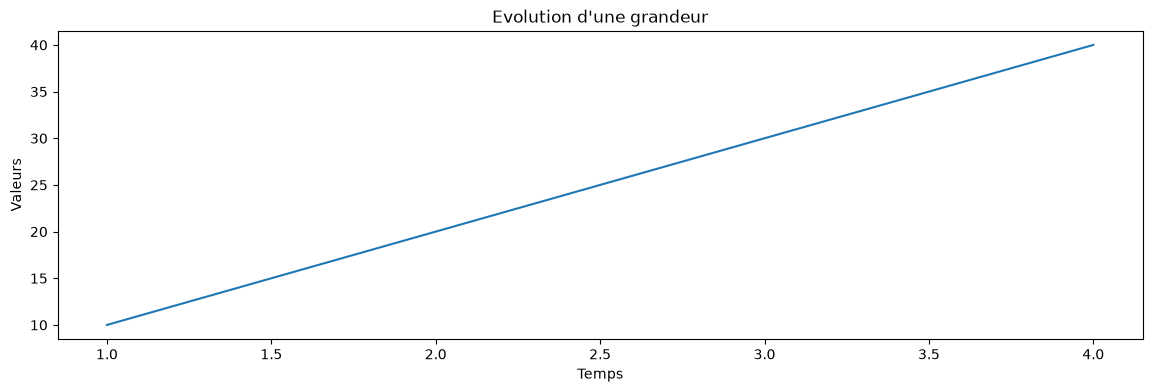

In [134]:
import matplotlib.pyplot as plt

# 1. Creation de la fugure et les axex
fid, ax = plt.subplots(figsize = (14,4))

# 2. Representation des données sur les axes
ax.plot([1, 2, 3, 4], [10, 20, 30, 40])

# 3. personnalisation des graohiques: 
ax.set_title("Evolution d'une grandeur")
ax.set_xlabel("Temps")
ax.set_ylabel("Valeurs")

# Affichage du graphique
plt.show()


`A retenir`

Ce cycle en quatre étapes (créer la gure, tracer, personnaliser, acher) reste le même quel
que soit le type de graphique : seule l'étape de tracé change (`plot`, `bar`, `scatter`, etc.).

#### `=== 3.3 Réalisation des graphiques ===`

##### `=== 3.3.1 Graphique linéaire (Line Plot) ===`

`Problème identifié`

On souhaite représenter l'évolution d'une grandeur continue (une mesure, un prix, une
métrique d'entraînement d'un modèle) au l du temps ou d'une autre variable ordonnée.

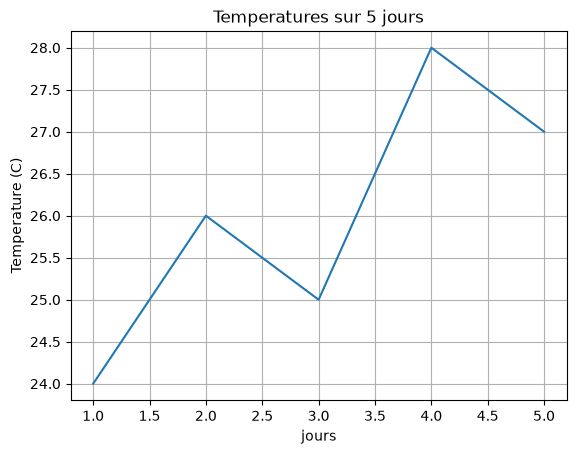

In [140]:
import matplotlib.pyplot as plt

jours = [1, 2, 3, 4, 5]
temperature = [24, 26, 25, 28, 27]

plt.plot(jours, temperature)
plt.title("Temperatures sur 5 jours")
plt.xlabel("jours")
plt.ylabel("Temperature (C)")
plt.grid()
plt.show()

##### `=== 3.3.2 Diagramme en barres (Bar Chart) ===`

`Problème identié`

On veut comparer des valeurs entre catégories distinctes (par exemple les ventes par produit),
où l'ordre n'a pas de sens continu contrairement à une évolution dans le temps.

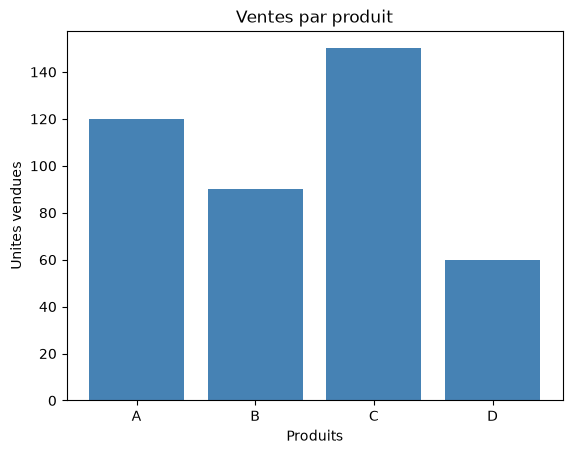

In [ ]:
produits = ["A", "B", "C", "D"]
ventes = [120, 90, 150, 60]

plt.bar(produits, ventes, color="steelblue")
plt.title("Ventes par produit")
plt.xlabel("Produit")
plt.ylabel("Unites vendues")
plt.show()

##### `=== 3.3.3 Histogramme ===`

`Problème identifié`

On veut comprendre comment se répartissent les valeurs d'une variable continue (par exemple la distribution des âges d'une population) : combien de valeurs tombent dans chaque intervalle.

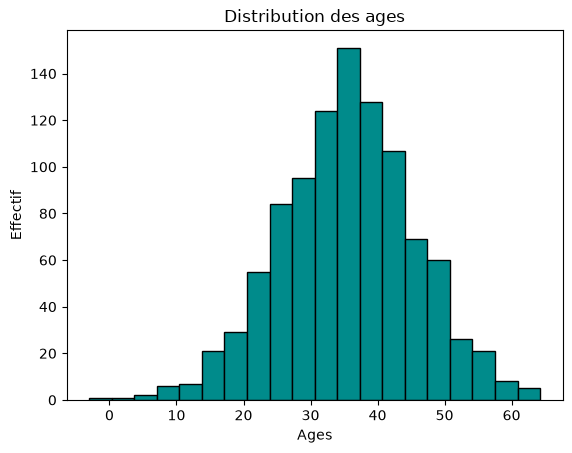

In [144]:
import matplotlib.pyplot as plt
import numpy as np

ages = np.random.normal(loc =35 , scale =10 , size =1000)

plt.hist(ages, bins=20, color="darkcyan", edgecolor = "black")
plt.title("Distribution des ages")
plt.xlabel("Ages")
plt.ylabel("Effectif")
plt.show()

`A retenir`

Ne pas confondre le `diagramme en barres` et l'`histogramme` : le premier compare des catégories distinctes, le second montre la répartition d'une variable continue découpée en intervalles
(bins).

##### `=== 3.3.4 Nuage de points (Scatter Plot) ===`

`Problème identifié`

On veut visualiser la relation entre deux variables numériques (par exemple, existe-t-il un lien entre le nombre d'heures de révision et la note obtenue) une information que ni une courbe ni un histogramme ne peuvent montrer directement.

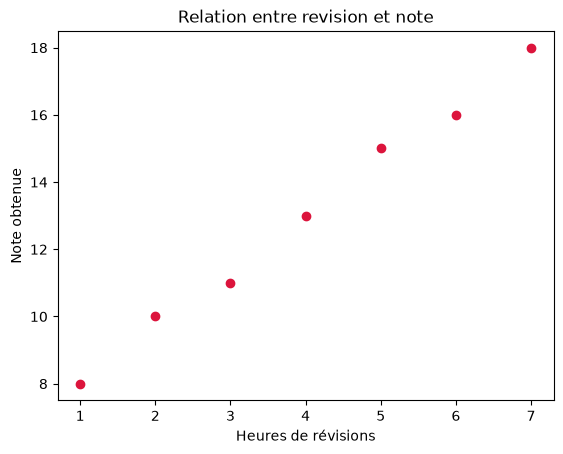

In [146]:
heures_revisions = [1 , 2 , 3 , 4 , 5 , 6 , 7]
notes = [8 , 10 , 11 , 13 , 15 , 16 , 18]

plt.scatter(heures_revisions, notes, color="crimson")
plt.title("Relation entre revision et note")
plt.xlabel("Heures de révisions")
plt.ylabel("Note obtenue")
plt.show()

##### `=== 3.3.5 Diagramme circulaire (Pie Chart) ===`

`Problème identifié`

On veut montrer la proportion relative de chaque catégorie par rapport à un total (par exemple la répartition des parts de marché).

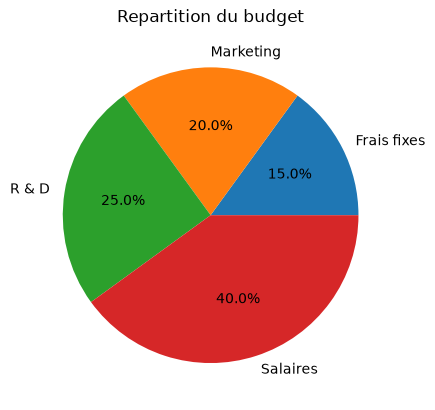

In [147]:
categories = [ "Frais fixes" , "Marketing" , "R & D" , "Salaires" ]
parts = [15 , 20 , 25 , 40]

plt.pie(parts, labels=categories, autopct = "%1.1f%%")
plt.title("Repartition du budget")
plt.show()

`A retenir`

Le `diagramme circulaire` devient illisible au-delà de 5 à 6 catégories : un diagramme en barres reste alors préférable pour comparer plus d'éléments.

##### `=== 3.4 Personnalisation des graphiques ===`

`Problème identifié`

Un graphique brut, sans titre ni légende ni indication d'unité, ne communique rien à un lecteur extérieur : il faut pouvoir l'annoter pour qu'il soit compréhensible seul, hors de son contexte de création.

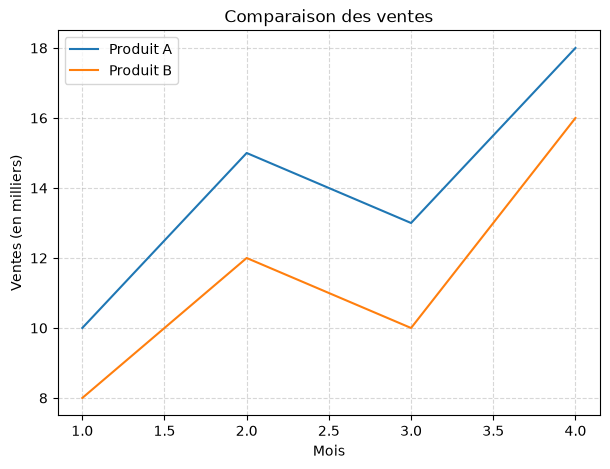

In [148]:
x = [1 , 2 , 3 , 4]
y1 = [10 , 15 , 13 , 18]
y2 = [8 , 12 , 10 , 16]

# taille de la figure
plt.figure(figsize=(7, 5))

plt.plot(x , y1 , label = "Produit A" )
plt.plot(x , y2 , label = "Produit B" )

plt.title("Comparaison des ventes")
plt.xlabel("Mois")
plt.ylabel("Ventes (en milliers)")
plt.legend()   # affiche la legende via le label

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


##### `=== 3.5 Gestion des couleurs et styles ===`

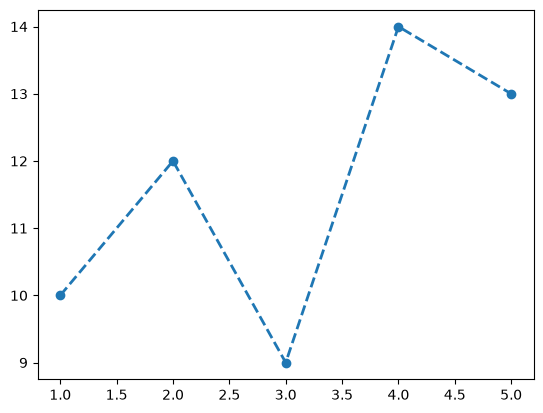

In [149]:
x = [1 , 2 , 3 , 4 , 5]
y = [10 , 12 , 9 , 14 , 13]

# color : couleur de la courbe ; linestyle : style du trait ;
# marker : symbole pour chaque point ; linewidth : epaisseur;

plt.plot(x , y , color = "#1f77b4" , linestyle ="--" , marker = "o" ,linewidth=2)
plt.show()


`A retenir`

Matplotlib accepte les couleurs sous plusieurs formes : nom `("red")`, code hexadécimal `("#1f77b4")`, ou tuple RGB. Parmi les styles de trait courants : `"-"` (plein), "" (tirets),
`":"` (pointillés), `"-." `(mixte).

##### `=== 3.6 Plusieurs courbes sur un même graphique ===`

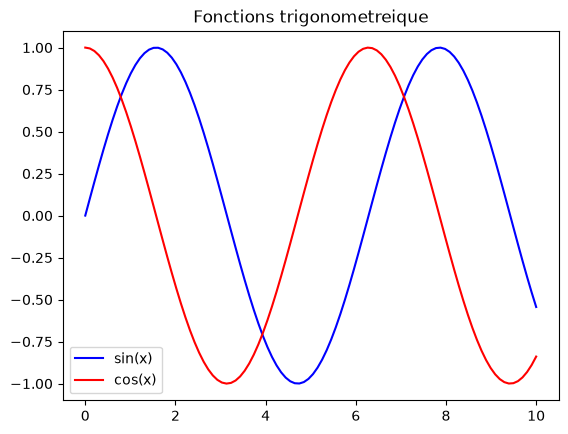

In [154]:
x = np.linspace(0 , 10 , 100)

plt.plot(x, np.sin(x), label="sin(x)", color="blue")
plt.plot(x, np.cos(x), label="cos(x)", color="red")

plt.title("Fonctions trigonometreique")
plt.legend()
plt.show()

`A retenir`

Chaque appel à `plt.plot()` avant un `plt.show()` ajoute une nouvelle courbe sur les mêmes axes : c'est ce mécanisme qui permet de superposer plusieurs séries pour les comparer visuellement.

##### `=== 3.7  Sauvegarde des graphiques ===`

`Problème idemtifié`

Un graphique aché à l'écran avec `plt.show()` n'est pas automatiquement conservé : pour l'insérer dans un rapport, une présentation ou un notebook partagé, il faut l'exporter en fichier image.

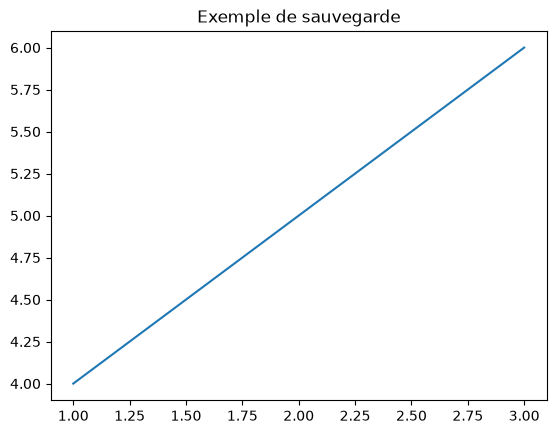

In [155]:
plt.plot([1 , 2 , 3] , [4 , 5 , 6])
plt.title("Exemple de sauvegarde")

# dpi : resolution; bbox_inches =" tight " evite de couper les labels
plt.savefig("graphique.png", dpi=300, bbox_inches="tight")

`A retenir`

`savefig()` doit être appelé avant `plt.show()` : une fois la gure achée puis fermée, `Matplotlib` vide son contenu et une sauvegarde après `show()` peut produire un chier vide.

## `=== Conclusion ===`